In [1]:
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
import time
from datetime import timedelta

In [2]:
class DoubleConv3D(nn.Module):
    """(3D convolution => LeakyReLU) * 2 with same padding"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.double_conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down3D(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool3d(2),
            DoubleConv3D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up3D(nn.Module):
    """Upscaling then double conv with skip connection"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv3D(out_channels * 2, out_channels) # we can put in_channel in first input

    def forward(self, x, skip):
        x = self.up(x)

        # Handle size mismatches automatically
        diffZ = skip.size()[2] - x.size()[2]
        diffY = skip.size()[3] - x.size()[3]
        diffX = skip.size()[4] - x.size()[4]
        
        # Apply padding if upsampled tensor is smaller
        x = nn.functional.pad(x, [diffX // 2, diffX - diffX // 2,
                      diffY // 2, diffY - diffY // 2,
                      diffZ // 2, diffZ - diffZ // 2])
        
        # Input and skip connection now have the same size
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class Surrogate3DPINN(nn.Module):
    """3D U-Net with padding to maintain spatial dimensions"""
    def __init__(self):
        super(Surrogate3DPINN, self).__init__()
        
        # Encoder
        self.inc = DoubleConv3D(2, 8)
        self.down1 = Down3D(8, 16)
        self.down2 = Down3D(16, 32)
        self.down3 = Down3D(32, 64)
        self.down4 = Down3D(64, 128)
        
        # Decoder
        self.up1 = Up3D(128, 64)
        self.up2 = Up3D(64, 32)
        self.up3 = Up3D(32, 16)
        self.up4 = Up3D(16, 8)
        
        # Output
        self.outc = nn.Conv3d(8, 1, kernel_size=1)

    def forward(self, conductivity, voltage_bc):

        x = torch.cat([conductivity, voltage_bc], dim=1)  # [batch, 2, D, H, W]
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        return self.outc(x)

In [3]:
def finite_difference_gradients_3d(potential: torch.Tensor, dx: float = 0.001) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute 3D gradients using finite differences"""
    # Initialize gradient tensors
    grad_x = torch.zeros_like(potential)
    grad_y = torch.zeros_like(potential)
    grad_z = torch.zeros_like(potential)
    
    # x-gradient (central difference for interior, forward/backward for boundaries)
    grad_x[:, :, 1:-1, :, :] = (potential[:, :, 2:, :, :] - potential[:, :, :-2, :, :]) / (2 * dx)
    grad_x[:, :, 0, :, :] = (potential[:, :, 1, :, :] - potential[:, :, 0, :, :]) / dx
    grad_x[:, :, -1, :, :] = (potential[:, :, -1, :, :] - potential[:, :, -2, :, :]) / dx
    
    # y-gradient
    grad_y[:, :, :, 1:-1, :] = (potential[:, :, :, 2:, :] - potential[:, :, :, :-2, :]) / (2 * dx)
    grad_y[:, :, :, 0, :] = (potential[:, :, :, 1, :] - potential[:, :, :, 0, :]) / dx
    grad_y[:, :, :, -1, :] = (potential[:, :, :, -1, :] - potential[:, :, :, -2, :]) / dx
    
    # z-gradient
    grad_z[:, :, :, :, 1:-1] = (potential[:, :, :, :, 2:] - potential[:, :, :, :, :-2]) / (2 * dx)
    grad_z[:, :, :, :, 0] = (potential[:, :, :, :, 1] - potential[:, :, :, :, 0]) / dx
    grad_z[:, :, :, :, -1] = (potential[:, :, :, :, -1] - potential[:, :, :, :, -2]) / dx
    
    return grad_x, grad_y, grad_z

def compute_pde_residual_map(potential: torch.Tensor, conductivity_map: torch.Tensor, dx: float = 0.001) -> torch.Tensor:
    """Compute ∇·(σ∇φ) = 0 residual in 3D using finite differences"""
    # Compute gradients ∇φ
    grad_x, grad_y, grad_z = finite_difference_gradients_3d(potential, dx)
    
    # Compute σ∇φ
    sigma_grad_x = conductivity_map * grad_x
    sigma_grad_y = conductivity_map * grad_y
    sigma_grad_z = conductivity_map * grad_z
    
    # Compute divergence ∇·(σ∇φ)
    div_x, _, _ = finite_difference_gradients_3d(sigma_grad_x, dx)
    _, div_y, _ = finite_difference_gradients_3d(sigma_grad_y, dx)
    _, _, div_z = finite_difference_gradients_3d(sigma_grad_z, dx)
    
    divergence = div_x + div_y + div_z
    
    return divergence

def compute_energy_density_map(potential, conductivity_map, dx=0.001):
    # Compute energy density: ½ σ |∇φ|²
    grad_x, grad_y, grad_z = finite_difference_gradients_3d(potential, dx)
    
    # |∇φ|² = (∂φ/∂x)² + (∂φ/∂y)² + (∂φ/∂z)²
    grad_squared = grad_x**2 + grad_y**2 + grad_z**2
    
    # Energy density: ½ σ |∇φ|²
    energy_density = 0.5 * conductivity_map * grad_squared
    
    return energy_density

def compute_electric_field(potential):
    """Compute electric field E = -∇φ"""
    grad_x, grad_y, grad_z = finite_difference_gradients_3d(potential)
    E_x = -grad_x
    E_y = -grad_y
    E_z = -grad_z
    E_magnitude = torch.sqrt(E_x**2 + E_y**2 + E_z**2)
    return E_x, E_y, E_z, E_magnitude

In [4]:
def _create_comprehensive_plots(potential, conductivity, E_magnitude, 
                                  energy_density, pde_residual, boundary_mask, slice_idx):
        """Create all visualization plots"""
        
        # Create 2x3 subplot figure
        fig, axes = plt.subplots(3, 2, figsize=(20, 20))
        axes = axes.flatten()
        
        # Plot 1: Electric Potential
        im1 = axes[0].imshow(potential[:, :, slice_idx], cmap='RdBu_r', vmin=-1, vmax=1)
        axes[0].set_title('Electric Potential (V)')
        #axes[0].contour(boundary_mask[:, :, slice_idx], levels=[0.5], colors='black', linewidths=2)
        plt.colorbar(im1, ax=axes[0])
        
        # Plot 2: Conductivity
        mask = conductivity > 100
        conductivity[mask] = 2
        im2 = axes[1].imshow(conductivity[:, :, slice_idx], cmap='hot')
        axes[1].set_title('Conductivity (S/m)')
        plt.colorbar(im2, ax=axes[1])
        
        # Plot 3: Electric Field Magnitude
        im3 = axes[2].imshow(E_magnitude[:, :, slice_idx], cmap='viridis')
        axes[2].set_title('Electric Field Magnitude (V/m)')
        plt.colorbar(im3, ax=axes[2])
        
        # Plot 4: Energy Density
        im4 = axes[3].imshow(energy_density[:, :, slice_idx], cmap='plasma')
        axes[3].set_title('Energy Density (J/m³)')
        plt.colorbar(im4, ax=axes[3])
        
        # Plot 5: PDE Residual
        im5 = axes[4].imshow(pde_residual[:, :, slice_idx], cmap='coolwarm')
        axes[4].set_title('PDE Residual')
        plt.colorbar(im5, ax=axes[4])
        
        # Plot 6: Current Flow (Quiver plot)
        # Sample every 4th point for clarity
        
        
        plt.tight_layout()
        plt.show()
        
        # Create 3D interactive visualization
        #self._create_3d_visualization(potential, E_magnitude, slice_idx)

In [5]:
def load_model(model, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model'])

In [6]:
def visualize_model(model: nn.Module , device: torch.device):
    """Test the trained model on test set"""
    model.eval()
   
    with torch.no_grad():
        
        conductivity_file = "D:/Results/FEM/conductavity/conductivity_map27_2.nii.gz"
        voltage_file = "D:/Results/FEM/conductavity/voltage_map27_2.nii.gz"
        conductivity_img = nib.load(conductivity_file)
        conductivity_data = conductivity_img.get_fdata().astype(np.float32)
        
        voltage_img = nib.load(voltage_file)
        voltage_data = voltage_img.get_fdata().astype(np.float32)
        
        conductivity_tensor = torch.from_numpy(conductivity_data)
        voltage_tensor = torch.from_numpy(voltage_data)
        boundary_mask = (voltage_tensor != 0)
        
        conductivity = conductivity_tensor.unsqueeze(0)
        voltage_bc = voltage_tensor.unsqueeze(0)
        boundary_mask = boundary_mask.unsqueeze(0)

        conductivity = conductivity.unsqueeze(0).to(device)
        voltage_bc = voltage_bc.unsqueeze(0).to(device)
        boundary_mask = boundary_mask.unsqueeze(0).to(device)
        
        start_time = time.time()            
        potential_pred = model(conductivity, voltage_bc)
        potential_pred = torch.where(boundary_mask, voltage_bc, potential_pred)
        total_time = time.time() - start_time
        print(f"predection time: {str(timedelta(seconds=total_time))}")
        #potential_pred[boundary_mask] = voltage_bc[boundary_mask]
        # Compute derived quantities
        E_x, E_y, E_z, E_magnitude = compute_electric_field(potential_pred)
        energy_density = compute_energy_density_map(potential_pred, conductivity)
        pde_residual = compute_pde_residual_map(potential_pred, conductivity)
        
        # Convert to numpy for visualization
        potential_np = potential_pred[0, 0].cpu().numpy()
        conductivity_np = conductivity[0, 0].cpu().numpy()
        potential_np [conductivity_np == 0] = 0
        E_magnitude_np = E_magnitude[0, 0].cpu().numpy()
        mask = create_boundary_mask(conductivity_np)
        E_magnitude_np[mask] = 0
        energy_density_np = energy_density[0, 0].cpu().numpy()
        pde_residual_np = pde_residual[0, 0].cpu().numpy()
        pde_residual_np[mask] = 0
        absolute_errors = np.abs(pde_residual_np)
        mean_absolute_error = np.mean(absolute_errors)
        print(f"mean absolute error: {mean_absolute_error}")
        boundary_mask_np = boundary_mask[0, 0].cpu().numpy()
        
        # Determine slice index if not provided
        slice_idx = potential_np.shape[2] // 2
        # Create comprehensive visualization
        _create_comprehensive_plots(
            potential_np, conductivity_np, E_magnitude_np, 
            energy_density_np, pde_residual_np, boundary_mask_np, 
            slice_idx
        )
        #save
        Save_E_nifti(E_x.cpu() , E_y.cpu() , E_z.cpu() , E_magnitude_np , conductivity_img, "D:/Results/FEM/Electric field energy train 5/PINN")

        

predection time: 0:00:00.690731
mean absolute error: 143.61756896972656


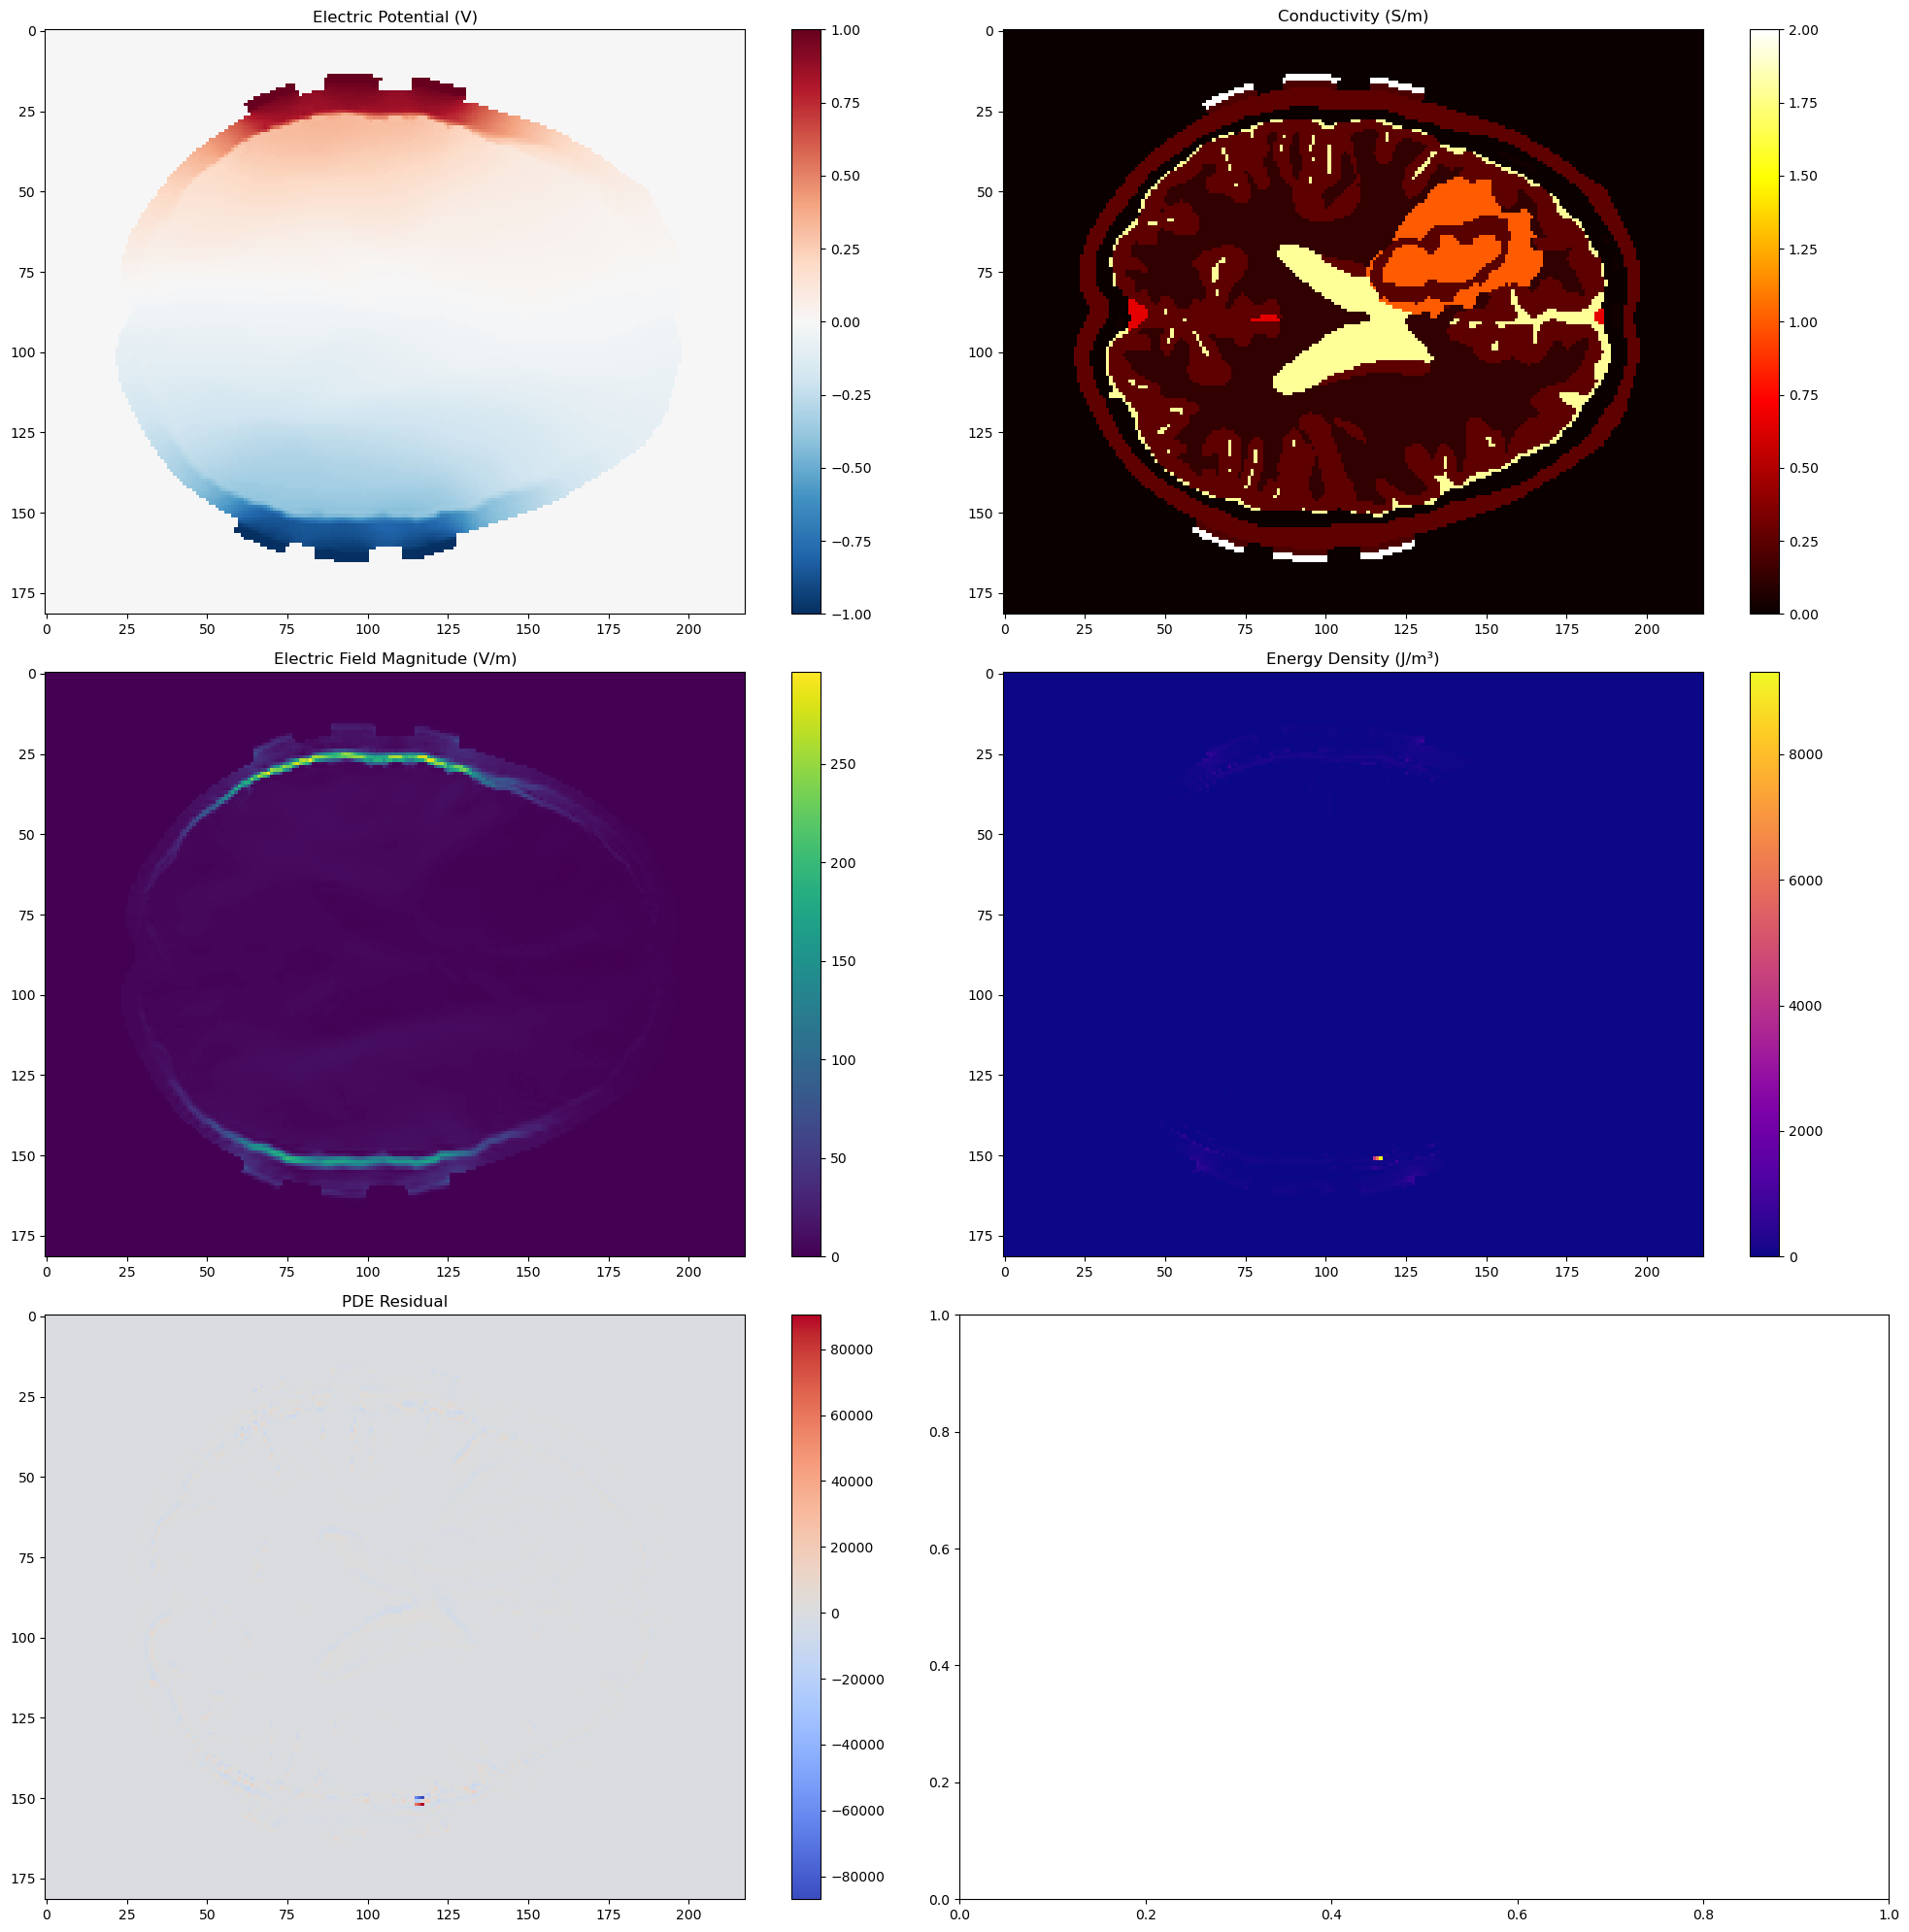

In [12]:

device = torch.device('cuda')

model = Surrogate3DPINN().to(device)
model = nn.DataParallel(model)
load_model(model , "D:/Results/Energy loss 2/train5.pth")

# Test
visualize_model(model, device)

mean absolute error: 449.0727853565515


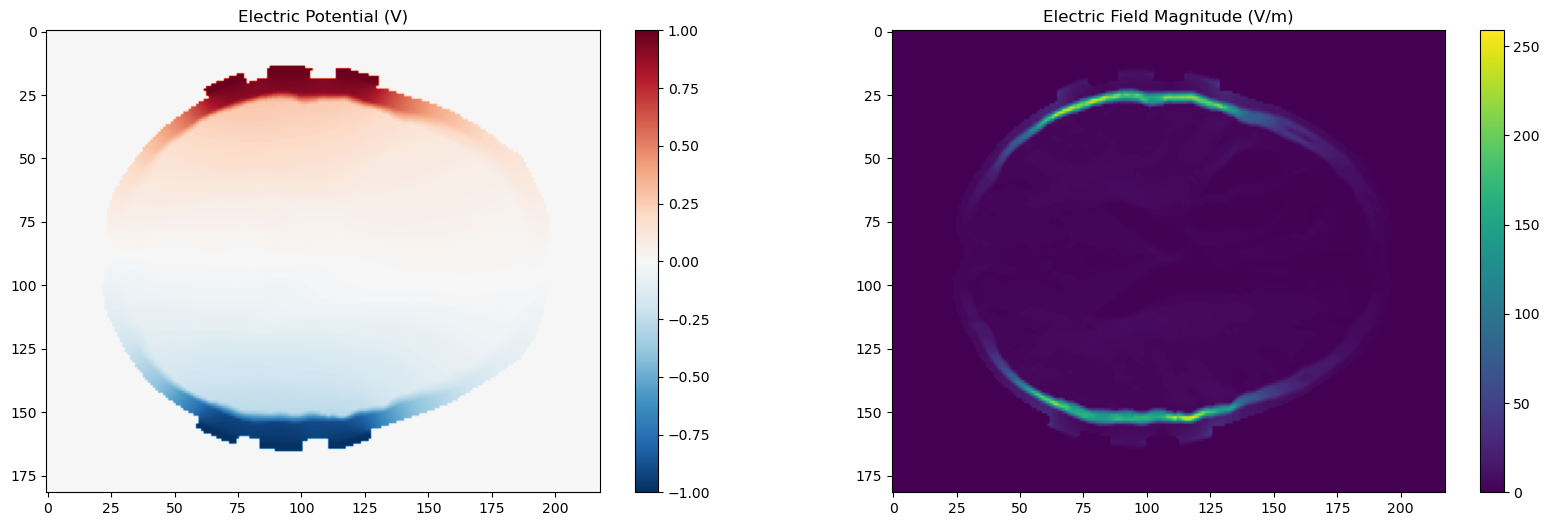

In [11]:
FEM_potential_file = "D:/Results/FEM/solution/solution_2_potential.nii.gz"
FEM_potential_img = nib.load(FEM_potential_file)
FEM_potential_data = FEM_potential_img.get_fdata()
FEM_potential_tensor = torch.from_numpy(FEM_potential_data)
FEM_potential_tensor = FEM_potential_tensor.unsqueeze(0)
FEM_potential_tensor = FEM_potential_tensor.unsqueeze(0)



E_x_FEM, E_y_FEM, E_z_FEM, E_magnitude_FEM = compute_electric_field(FEM_potential_tensor)
E_magnitude_np_FEM = E_magnitude_FEM[0, 0].numpy()
slice_idx = FEM_potential_data.shape[0] // 2

conductivity_file = "D:/Results/FEM/conductavity/conductivity_map27_2.nii.gz"
cond_img = nib.load(conductivity_file)
cond_data = cond_img.get_fdata()
mask = create_boundary_mask(cond_data)
cond_tensor = torch.from_numpy(cond_data)
cond_tensor = cond_tensor.unsqueeze(0)
cond_tensor = cond_tensor.unsqueeze(0)

pde_residual = compute_pde_residual_map(FEM_potential_tensor, cond_tensor)
pde_residual_np = pde_residual[0, 0].numpy()
pde_residual_np[mask] = 0
absolute_errors = np.abs(pde_residual_np)
mean_absolute_error = np.mean(absolute_errors)
print(f"mean absolute error: {mean_absolute_error}")


E_magnitude_np_FEM[mask] = 0
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
axes = axes.flatten()

# Plot 1: Electric Potential
im1 = axes[0].imshow(FEM_potential_data[:, :, slice_idx], cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Electric Potential (V)')
plt.colorbar(im1, ax=axes[0])

# Plot 3: Electric Field Magnitude
im3 = axes[1].imshow(E_magnitude_np_FEM[:, :, slice_idx], cmap='viridis')
axes[1].set_title('Electric Field Magnitude (V/m)')
plt.colorbar(im3, ax=axes[1])



##save
Save_E_nifti(E_x_FEM , E_y_FEM , E_z_FEM , E_magnitude_np_FEM , FEM_potential_img , "D:/Results/FEM/Electric field energy train 5/FEM")

In [8]:
from scipy import ndimage

def create_boundary_mask(cond_data, neighbor_distance=1):
    
    # Load conductivity image
    
    
    # Create air mask (where conductivity is 0 or near 0)
    air_mask = cond_data <= 1e-6  # Threshold for "zero" conductivity
    
    # Create boundary mask: voxels adjacent to air in any direction
    # Use 3D convolution to find neighbors
    kernel = np.ones((3, 3, 3), dtype=bool)
    kernel[1, 1, 1] = False  # Center voxel
    
    # Dilate air mask to include neighbors
    dilated_air = ndimage.binary_dilation(air_mask, structure=kernel, 
                                         iterations=neighbor_distance)
    
    # Boundary voxels are those that are conducting but adjacent to air
    boundary_mask = dilated_air
  
    
    return boundary_mask

In [9]:
import os
def Save_E_nifti(Ex_Tensor ,Ey_Tensor,Ez_Tensor , E_magnatude , reference_image , output_base):
    E_x_FEM_data = Ex_Tensor[0, 0].numpy()
    E_x_FEM_data[mask] = 0
    E_x_FEM_image = nib.Nifti1Image(E_x_FEM_data, reference_image.affine , reference_image.header)
    
    nib.save(E_x_FEM_image, os.path.join(output_base, 'Ex_2.nii.gz'))
    
    E_y_FEM_data = Ey_Tensor[0, 0].numpy()
    E_y_FEM_data[mask] = 0
    E_y_FEM_image = nib.Nifti1Image(E_y_FEM_data, reference_image.affine , reference_image.header)
    nib.save(E_y_FEM_image, os.path.join(output_base, 'Ey_2.nii.gz'))
    
    E_z_FEM_data = Ez_Tensor[0, 0].numpy()
    E_z_FEM_data[mask] = 0
    E_z_FEM_image = nib.Nifti1Image(E_z_FEM_data, reference_image.affine , reference_image.header)
    nib.save(E_z_FEM_image, os.path.join(output_base, 'Ez_2.nii.gz'))
    
    E_magnitude_FEM_image = nib.Nifti1Image(E_magnatude, reference_image.affine , reference_image.header)
    nib.save(E_magnitude_FEM_image, os.path.join(output_base, 'Emagnatude_2.nii.gz'))